# 🏦 Company Bankruptcy Prediction
## BFSI Domain | Binary Classification Project

**Objective:** Build a machine learning model to predict whether a company will go bankrupt based on 94 financial indicators.

**Dataset:** 6,819 rows × 95 columns  
**Target:** `Bankrupt` → 1 = Bankrupt, 0 = Not Bankrupt

---
### Project Pipeline
1. Import Libraries
2. Load & Understand Data
3. Exploratory Data Analysis (EDA)
4. Data Preprocessing
5. Handle Class Imbalance (SMOTE)
6. Feature Selection
7. Model Building & Evaluation
8. Hyperparameter Tuning
9. Final Model & Business Insights

---
## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size']  = 11

from sklearn.preprocessing   import RobustScaler
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                      cross_val_score, RandomizedSearchCV)
from sklearn.linear_model  import LogisticRegression
from sklearn.tree          import DecisionTreeClassifier
from sklearn.ensemble      import (RandomForestClassifier,
                                    GradientBoostingClassifier,
                                    AdaBoostClassifier)
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, precision_recall_curve,
                              f1_score, average_precision_score,
                              ConfusionMatrixDisplay, recall_score, precision_score)


All libraries imported successfully!


---
## Step 2: Load & Understand Data

In [2]:
df = pd.read_csv("BANKRUPTCY PREDICTION  -DATASCIENCE DATASET.csv")
df.columns = df.columns.str.strip()   # remove leading/trailing spaces

print('Shape:', df.shape)
df.head()

Shape: (6819, 95)


,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,Continuous interest rate (after tax),...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Equity to Liability,Bankrupt
0,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,0.780985,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,0.016469,1
1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,0.781506,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,0.020794,1
2,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,0.780284,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,0.016474,1


In [3]:
print(f'Rows    : {df.shape[0]}')
print(f'Columns : {df.shape[1]}  (including target)')
print(f'Missing : {df.isnull().sum().sum()}')
print(f'Dupes   : {df.duplicated().sum()}')
print(f'Dtypes  :\n{df.dtypes.value_counts()}')

Rows    : 6819
Columns : 95  (including target)
Missing : 0
Dupes   : 0
Dtypes  :
float64    93
int64       2
Name: count, dtype: int64


In [4]:
df.describe().T.round(4)

,count,mean,std,min,25%,50%,75%,max
ROA(C) before interest and depreciation before interest,6819.0,0.5052,0.0607,0.0,0.4765,0.5027,0.5356,1.0
ROA(A) before interest and % after tax,6819.0,0.5586,0.0656,0.0,0.5355,0.5598,0.5892,1.0
ROA(B) before interest and depreciation after tax,6819.0,0.5536,0.0616,0.0,0.5273,0.5523,0.5841,1.0
Operating Gross Margin,6819.0,0.6079,0.0169,0.0,0.6004,0.6060,0.6139,1.0
Realized Sales Gross Margin,6819.0,0.6079,0.0169,0.0,0.6004,0.6060,0.6138,1.0
...,...,...,...,...,...,...,...,...
Liability to Equity,6819.0,0.2804,0.0145,0.0,0.2769,0.2788,0.2814,1.0
Degree of Financial Leverage (DFL),6819.0,0.0275,0.0157,0.0,0.0268,0.0268,0.0269,1.0
Interest Coverage Ratio (Interest expense to EBIT),6819.0,0.5654,0.0132,0.0,0.5652,0.5653,0.5657,1.0
Equity to Liability,6819.0,0.0476,0.0500,0.0,0.0245,0.0338,0.0528,1.0


In [5]:
# Remove duplicates if any
if df.duplicated().sum() > 0:
    df = df.drop_duplicates()
    print(f'Duplicates removed. New shape: {df.shape}')
else:
    print('No duplicate rows found.')

No duplicate rows found.


---
## Step 3: Exploratory Data Analysis (EDA)

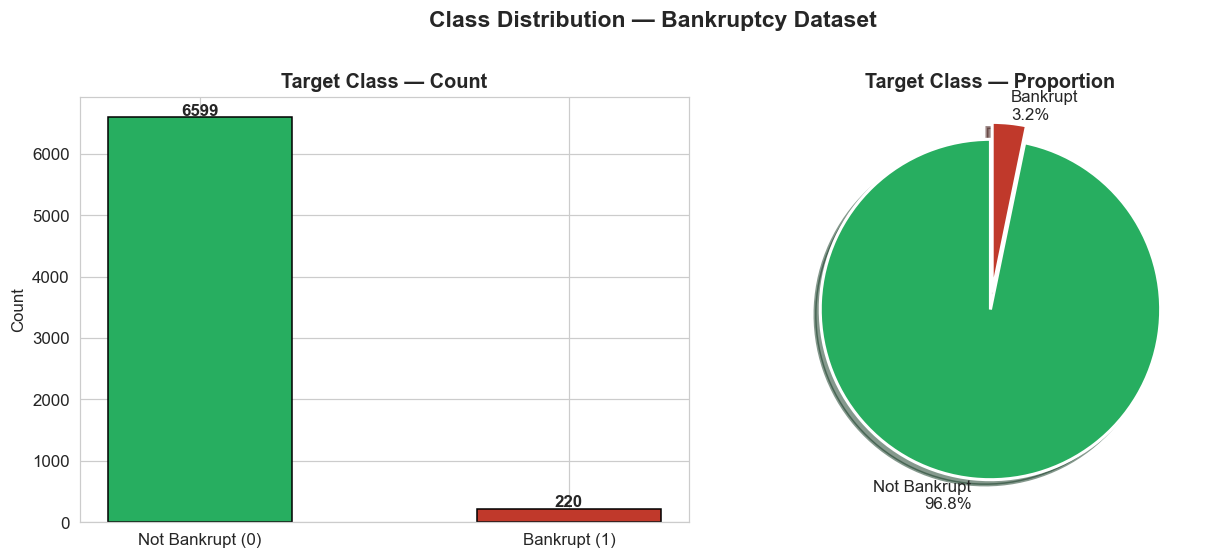

Not Bankrupt : 6,599  (96.8%)
Bankrupt     : 220  (3.2%)
Imbalance    : 29 : 1  --> Must handle!


In [6]:
# 3.1 Target Variable Distribution
counts = df['Bankrupt'].value_counts()
pct    = df['Bankrupt'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
clrs = ['#27ae60', '#c0392b']

bars = axes[0].bar(['Not Bankrupt (0)', 'Bankrupt (1)'], counts.values,
                    color=clrs, edgecolor='black', width=0.5)
axes[0].set_title('Target Class — Count', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+30, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values,
            labels=[f'Not Bankrupt\n{pct[0]:.1f}%', f'Bankrupt\n{pct[1]:.1f}%'],
            colors=clrs, startangle=90, explode=(0,0.1), shadow=True,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Target Class — Proportion', fontsize=13, fontweight='bold')

plt.suptitle('Class Distribution — Bankruptcy Dataset', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f'Not Bankrupt : {counts[0]:,}  ({pct[0]:.1f}%)')
print(f'Bankrupt     : {counts[1]:,}  ({pct[1]:.1f}%)')
print(f'Imbalance    : {int(counts[0]/counts[1])} : 1')

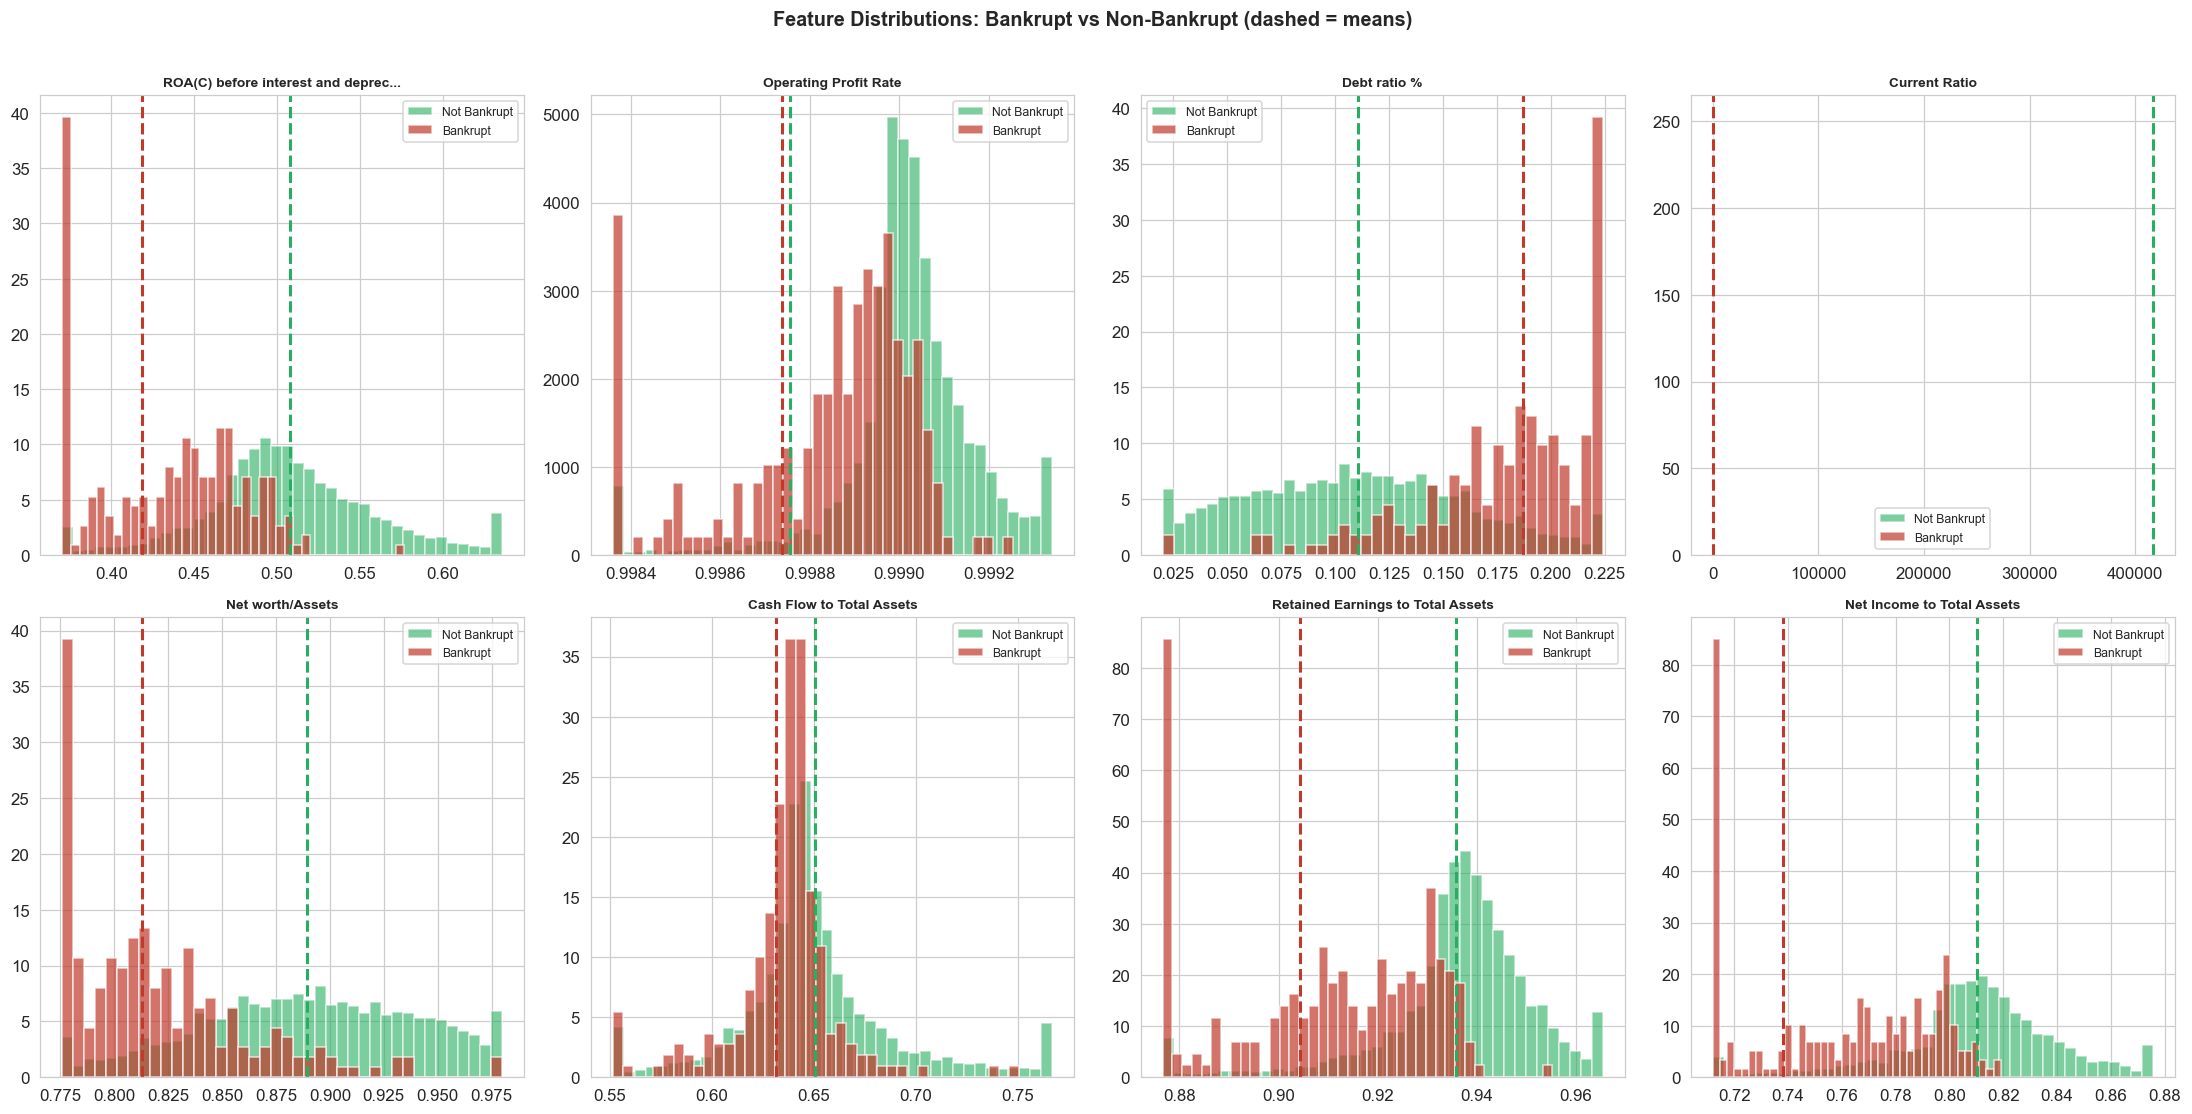

In [7]:
# 3.2 Feature Distributions for Key Financial Ratios
key_features = [
    'ROA(C) before interest and depreciation before interest',
    'Operating Profit Rate',
    'Debt ratio %',
    'Current Ratio',
    'Net worth/Assets',
    'Cash Flow to Total Assets',
    'Retained Earnings to Total Assets',
    'Net Income to Total Assets'
]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    b0 = df[df['Bankrupt']==0][feat].dropna()
    b1 = df[df['Bankrupt']==1][feat].dropna()
    lo, hi = np.percentile(df[feat].dropna(), [2, 98])
    axes[i].hist(b0.clip(lo,hi), bins=40, alpha=0.6, color='#27ae60', label='Not Bankrupt', density=True)
    axes[i].hist(b1.clip(lo,hi), bins=40, alpha=0.7, color='#c0392b', label='Bankrupt', density=True)
    axes[i].axvline(b0.mean(), color='#27ae60', linestyle='--', lw=2)
    axes[i].axvline(b1.mean(), color='#c0392b', linestyle='--', lw=2)
    name = feat[:33]+'...' if len(feat)>33 else feat
    axes[i].set_title(name, fontsize=9, fontweight='bold')
    axes[i].legend(fontsize=8)

plt.suptitle('Feature Distributions: Bankrupt vs Non-Bankrupt (dashed = means)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

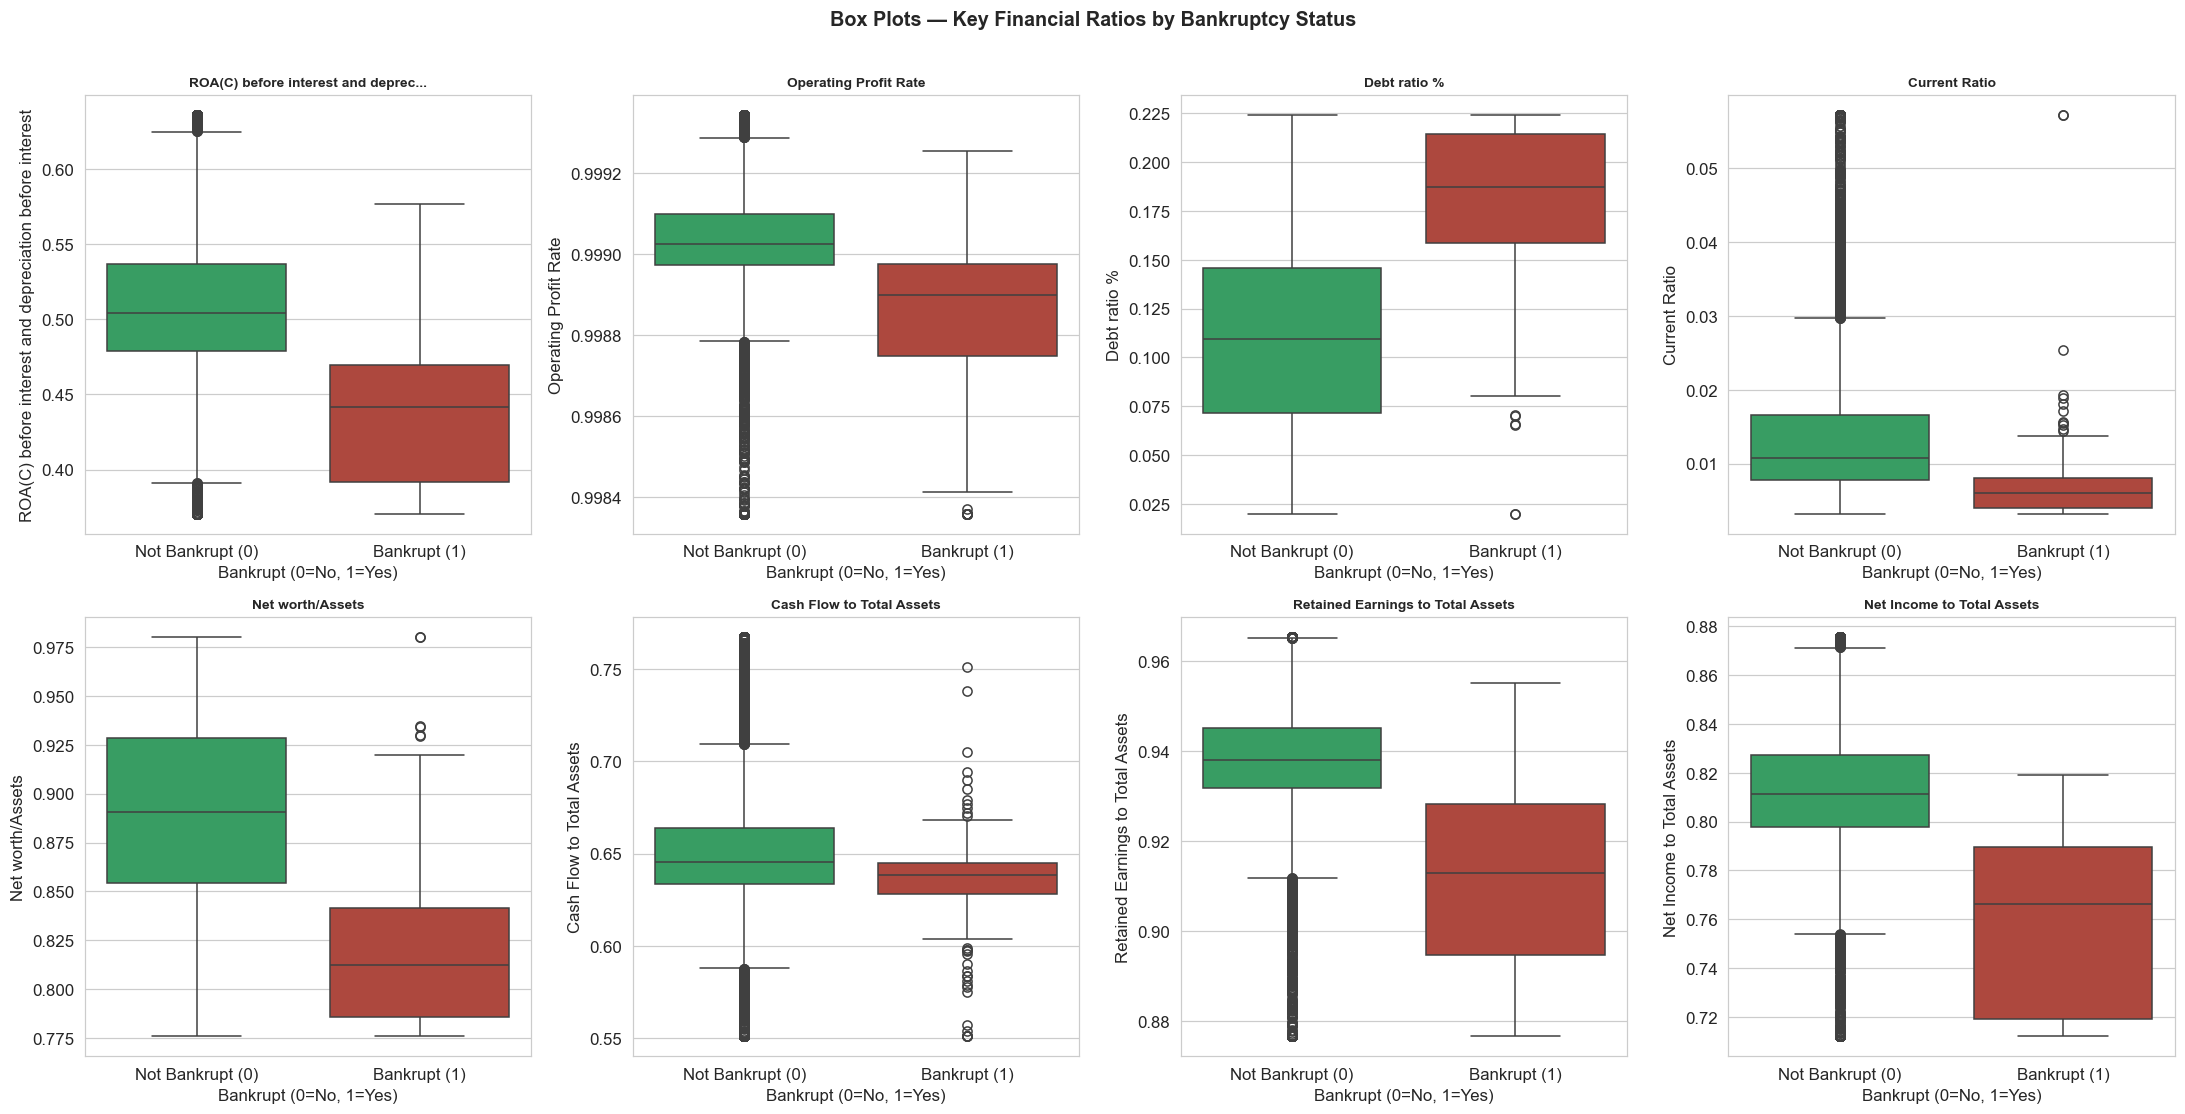

In [8]:
# 3.3 Box Plots
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    lo, hi = np.percentile(df[feat].dropna(), [2,98])
    tmp = df[['Bankrupt', feat]].copy()
    tmp[feat] = tmp[feat].clip(lo, hi)
    # Convert to string so palette keys always match seaborn's hue values
    tmp['Bankrupt'] = tmp['Bankrupt'].astype(str)
    sns.boxplot(data=tmp, x='Bankrupt', y=feat, ax=axes[i],
                palette={'0':'#27ae60','1':'#c0392b'},
                order=['0','1'])
    axes[i].set_xticklabels(['Not Bankrupt (0)', 'Bankrupt (1)'])
    name = feat[:33]+'...' if len(feat)>33 else feat
    axes[i].set_title(name, fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Bankrupt (0=No, 1=Yes)')

plt.suptitle('Box Plots — Key Financial Ratios by Bankruptcy Status',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

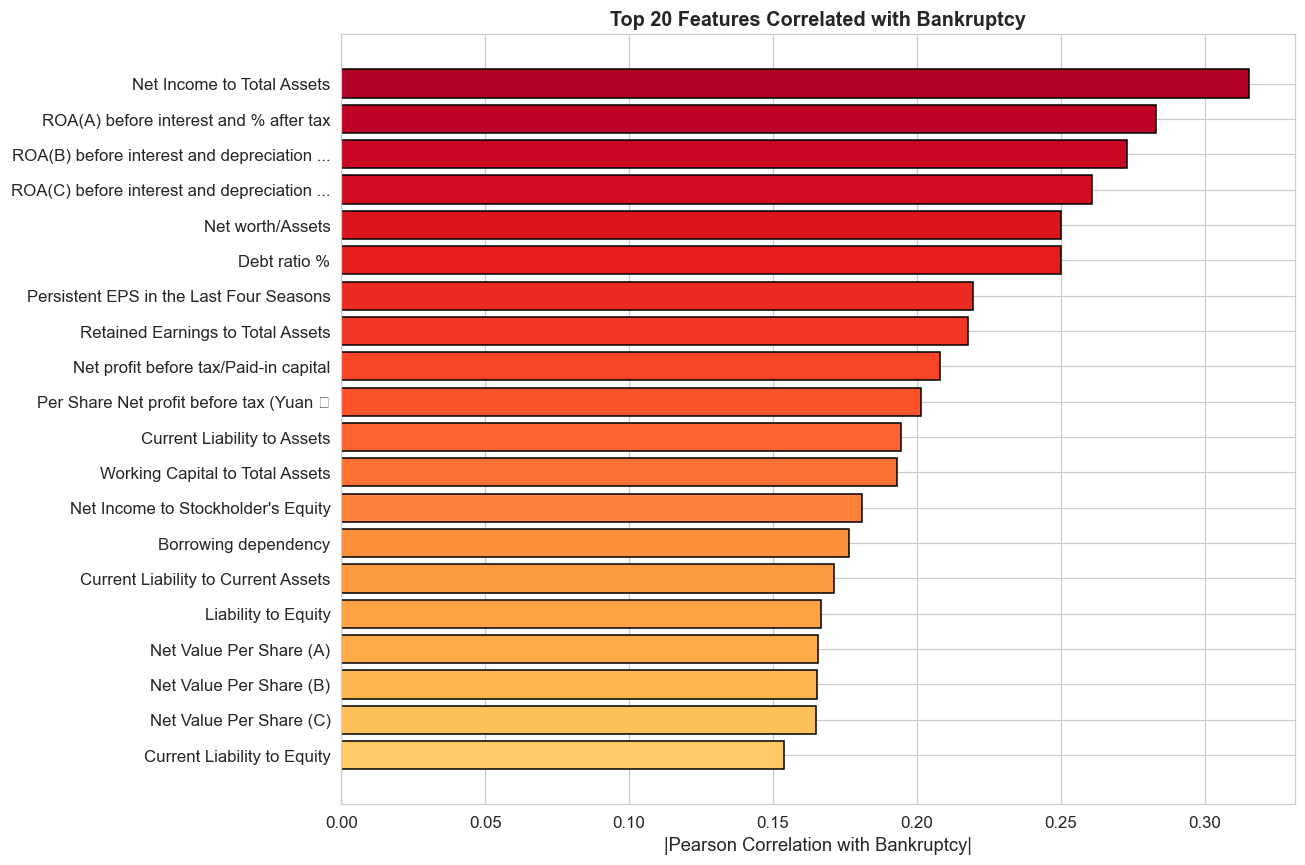

Top 10:
Net Income to Total Assets                                 0.3155
ROA(A) before interest and % after tax                     0.2829
ROA(B) before interest and depreciation after tax          0.2731
ROA(C) before interest and depreciation before interest    0.2608
Net worth/Assets                                           0.2502
Debt ratio %                                               0.2502
Persistent EPS in the Last Four Seasons                    0.2196
Retained Earnings to Total Assets                          0.2178
Net profit before tax/Paid-in capital                      0.2079
Per Share Net profit before tax (Yuan �                    0.2014
Name: Bankrupt, dtype: float64


In [9]:
# 3.4 Top 20 Features Correlated with Bankruptcy
corr_tgt = df.corr()['Bankrupt'].drop('Bankrupt').abs().sort_values(ascending=False)
top20_c  = corr_tgt.head(20)
short_c  = [n[:40]+'...' if len(n)>40 else n for n in top20_c.index]

plt.figure(figsize=(12, 8))
cmap_c = plt.cm.YlOrRd(np.linspace(0.3, 0.9, 20))
plt.barh(short_c[::-1], top20_c.values[::-1], color=cmap_c, edgecolor='black')
plt.xlabel('|Pearson Correlation with Bankruptcy|', fontsize=12)
plt.title('Top 20 Features Correlated with Bankruptcy', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Top 10:')
print(corr_tgt.head(10).round(4))

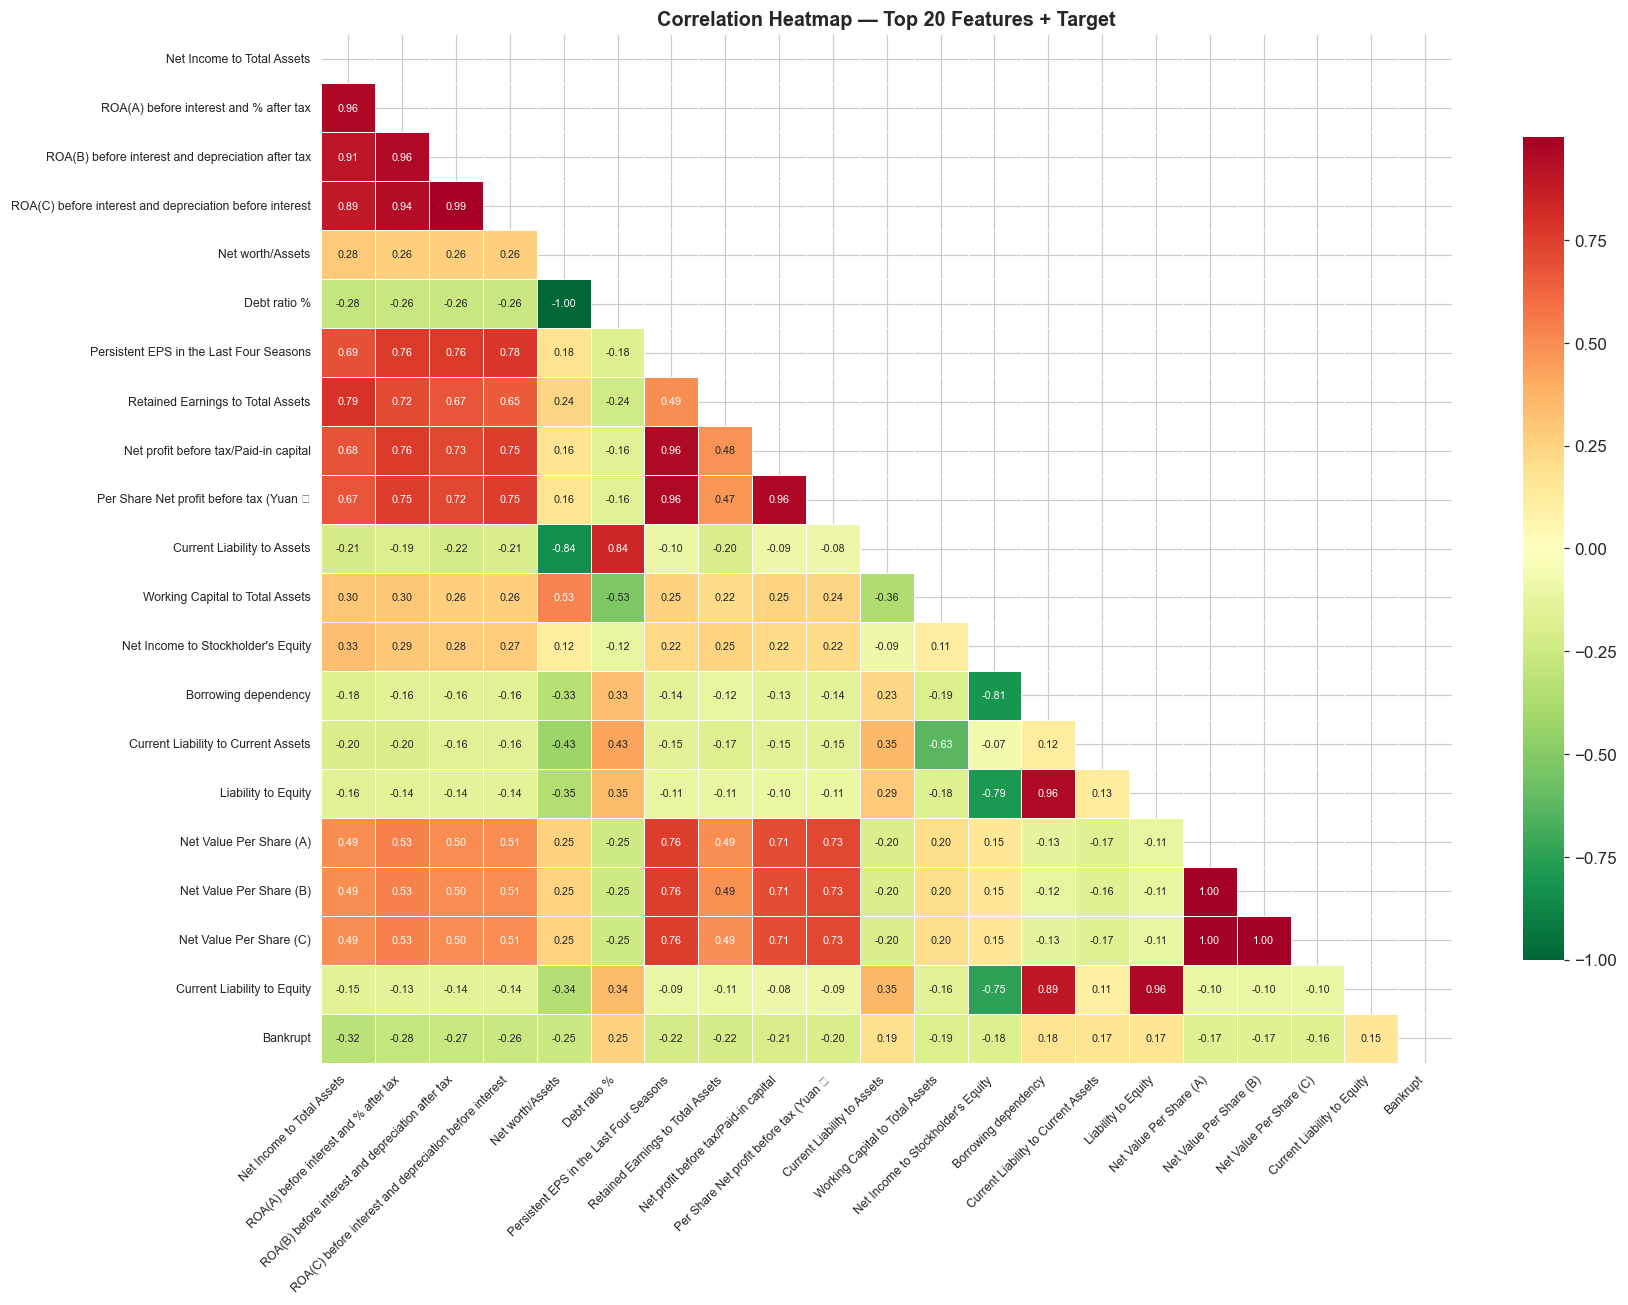

In [10]:
# 3.5 Correlation Heatmap (Top 20 Features + Target)
top20_feats = corr_tgt.head(20).index.tolist()
corr_hm = df[top20_feats + ['Bankrupt']].corr()
mask = np.triu(np.ones_like(corr_hm, dtype=bool))

plt.figure(figsize=(16, 12))
sns.heatmap(corr_hm, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn_r',
            linewidths=0.5, cbar_kws={'shrink':0.8}, annot_kws={'size':7})
plt.title('Correlation Heatmap — Top 20 Features + Target',
          fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

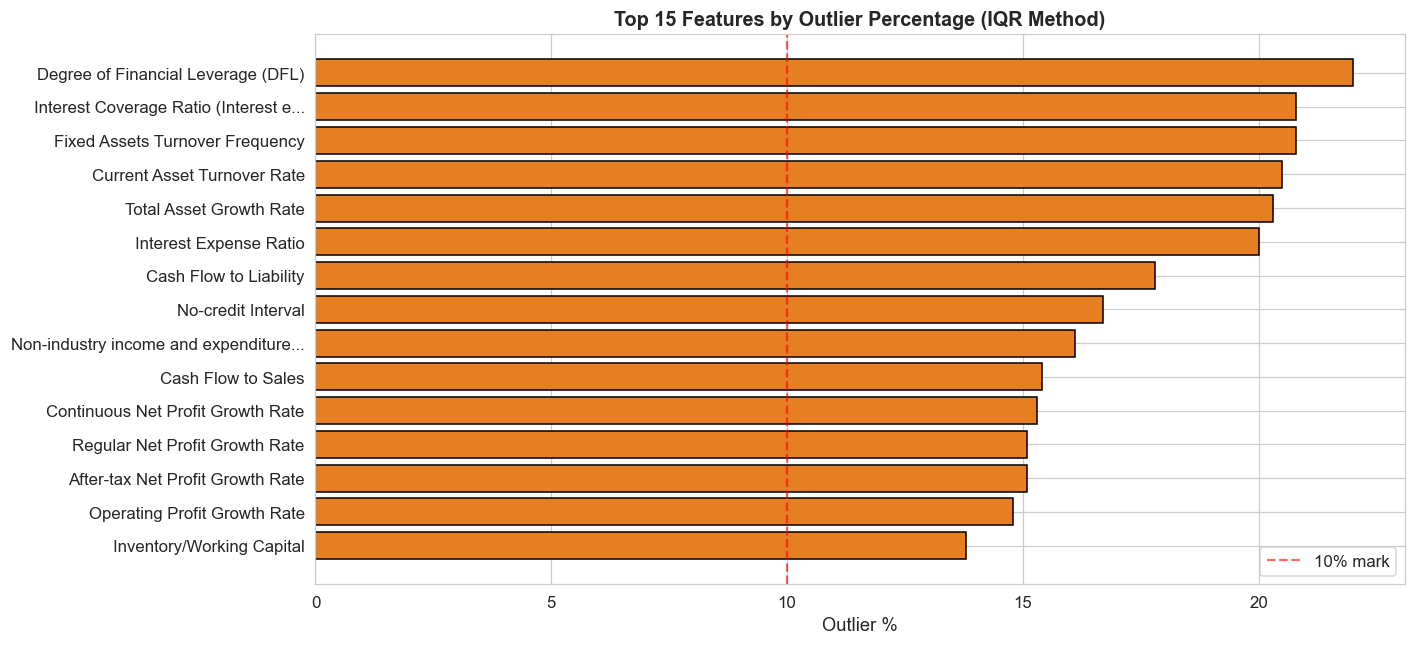

Features with >10% outliers: 30


In [11]:
# 3.6 Outlier Detection via IQR
feat_cols = df.columns[:-1].tolist()
out_data  = []
for col in feat_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n = ((df[col] < Q1-1.5*IQR) | (df[col] > Q3+1.5*IQR)).sum()
    out_data.append({'Feature': col, 'Outlier %': round(n/len(df)*100,1)})

out_df = pd.DataFrame(out_data).sort_values('Outlier %', ascending=False)
top15o = out_df.head(15)
short_o = [n[:35]+'...' if len(n)>35 else n for n in top15o['Feature']]

plt.figure(figsize=(13, 6))
plt.barh(short_o[::-1], top15o['Outlier %'].values[::-1], color='#e67e22', edgecolor='black')
plt.axvline(10, color='red', linestyle='--', alpha=0.6, label='10% mark')
plt.xlabel('Outlier %', fontsize=12)
plt.title('Top 15 Features by Outlier Percentage (IQR Method)', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Features with >10% outliers: {(out_df["Outlier %"]>10).sum()}')

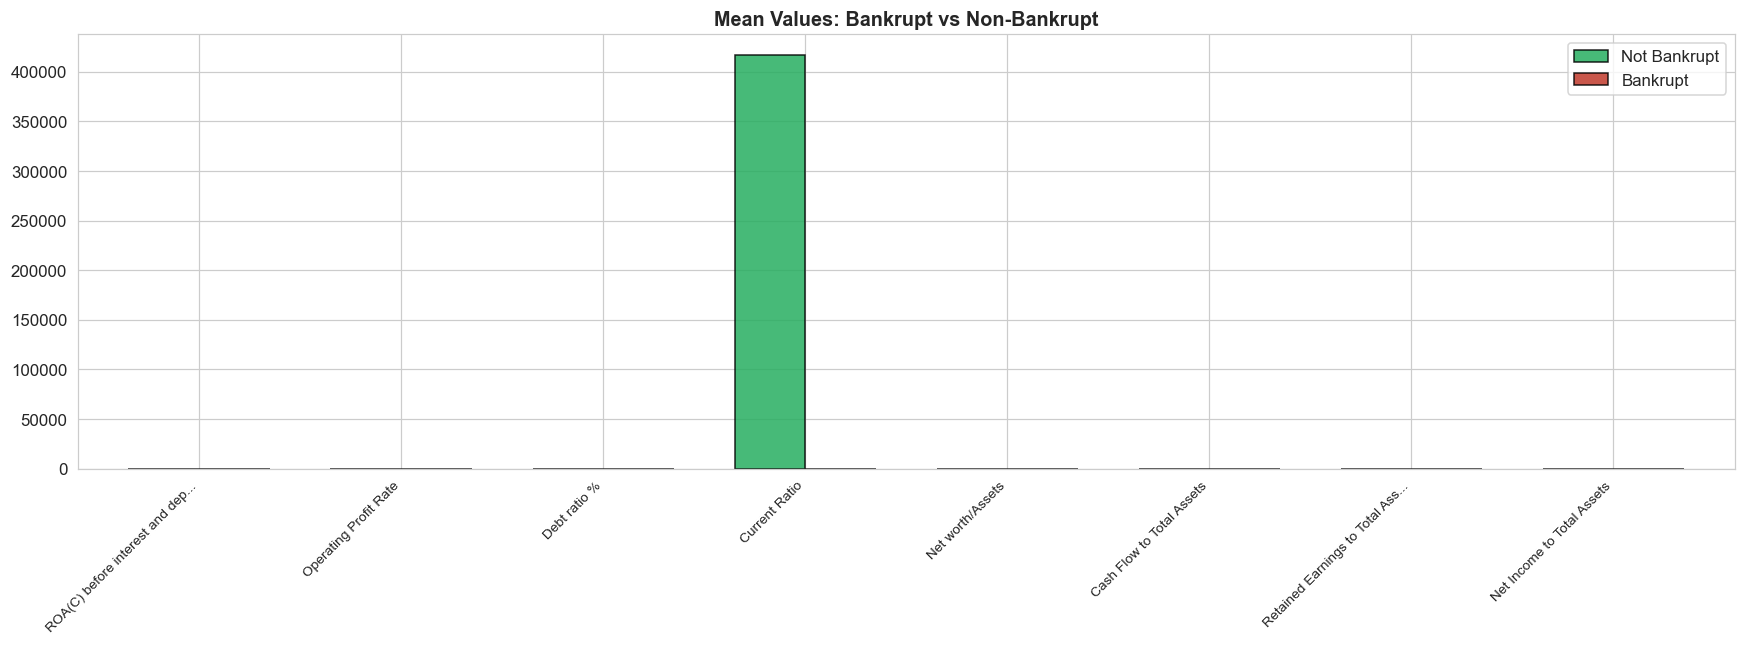

In [12]:
# 3.7 Mean Comparison Bar Chart
b0m = df[df['Bankrupt']==0][key_features].mean()
b1m = df[df['Bankrupt']==1][key_features].mean()
cmp = pd.DataFrame({'Not Bankrupt': b0m, 'Bankrupt': b1m})
cmp.index = [n[:30]+'...' if len(n)>30 else n for n in cmp.index]

cmp.plot(kind='bar', figsize=(16,6), color=['#27ae60','#c0392b'],
          edgecolor='black', width=0.7, alpha=0.85)
plt.title('Mean Values: Bankrupt vs Non-Bankrupt', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

---
## Step 4: Data Preprocessing

In [13]:
# 4.1 Separate Features & Target
X = df.drop('Bankrupt', axis=1).copy()
y = df['Bankrupt'].copy()
print(f'X shape: {X.shape},  y shape: {y.shape}')

X shape: (6819, 94),  y shape: (6819,)


In [14]:
# 4.2 Drop highly correlated features (>0.92)
corr_X = X.corr().abs()
upper  = corr_X.where(np.triu(np.ones(corr_X.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.92)]

X = X.drop(columns=to_drop)
print(f'Dropped {len(to_drop)} high-corr features.  Remaining: {X.shape[1]}')

Dropped 18 high-corr features.  Remaining: 76


In [15]:
# 4.3 Winsorization (clip at 1st and 99th percentile)
def winsorize(df_in, lo_q=0.01, hi_q=0.99):
    df_out = df_in.copy()
    for col in df_out.columns:
        lo = df_out[col].quantile(lo_q)
        hi = df_out[col].quantile(hi_q)
        df_out[col] = df_out[col].clip(lo, hi)
    return df_out

X = winsorize(X)
print('Winsorization applied.')

Winsorization applied.


In [16]:
# 4.4 Stratified Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f'Train: {X_train.shape}  Bankrupt={y_train.sum()} ({y_train.mean()*100:.1f}%)')
print(f'Test : {X_test.shape}   Bankrupt={y_test.sum()}  ({y_test.mean()*100:.1f}%)')

Train: (5455, 76)  Bankrupt=176 (3.2%)
Test : (1364, 76)   Bankrupt=44  (3.2%)


In [17]:
# 4.5 RobustScaler
scaler = RobustScaler()
X_train_s = scaler.fit_transform(X_train)  # fit on train only
X_test_s  = scaler.transform(X_test)
feature_names = X.columns.tolist()
print('RobustScaler applied.')

RobustScaler applied.


---
## Step 5: Handle Class Imbalance (SMOTE)

In [18]:
# Manual SMOTE implementation
def smote(X, y, target_class=1, k=5, random_state=42):
    np.random.seed(random_state)
    min_idx = np.where(y == target_class)[0]
    maj_idx = np.where(y != target_class)[0]
    X_min = X[min_idx]
    n_gen  = len(maj_idx) - len(min_idx)
    synth  = []
    for _ in range(n_gen):
        i  = np.random.randint(len(X_min))
        s  = X_min[i]
        d  = np.linalg.norm(X_min - s, axis=1)
        d[i] = np.inf
        nn = np.random.choice(np.argsort(d)[:k])
        a  = np.random.uniform(0, 1)
        synth.append(s + a * (X_min[nn] - s))
    X_syn = np.array(synth)
    y_syn = np.ones(n_gen, dtype=int)
    X_res = np.vstack([X, X_syn])
    y_res = np.concatenate([y, y_syn])
    perm  = np.random.permutation(len(X_res))
    return X_res[perm], y_res[perm]

print('Applying SMOTE to training data (minority class upsampled to match majority)...')
X_train_sm, y_train_sm = smote(X_train_s, y_train.values, target_class=1, k=5)

before = pd.Series(y_train).value_counts().sort_index()
after  = pd.Series(y_train_sm).value_counts().sort_index()
print(f'Before: {dict(before)}')
print(f'After : {dict(after)}')

Applying SMOTE to training data (minority class upsampled to match majority)...
Before: {0: 5279, 1: 176}
After : {0: 5279, 1: 5279}


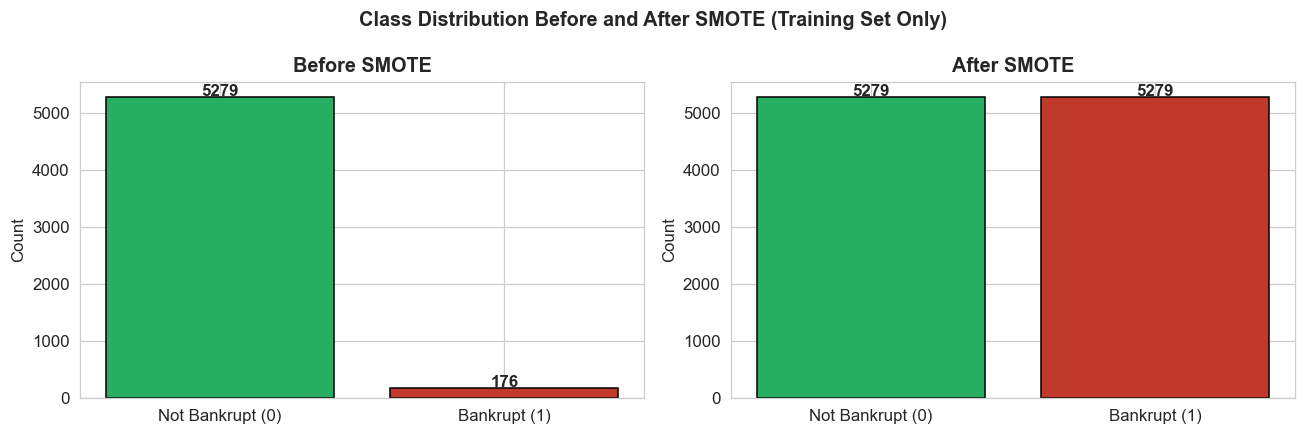

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
labels = ['Not Bankrupt (0)', 'Bankrupt (1)']
clrs   = ['#27ae60','#c0392b']

for ax, vals, title in [
    (axes[0], [before[0], before[1]], 'Before SMOTE'),
    (axes[1], [after[0],  after[1]],  'After SMOTE')
]:
    bars = ax.bar(labels, vals, color=clrs, edgecolor='black')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Count')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, v+20, str(v), ha='center', fontweight='bold')

plt.suptitle('Class Distribution Before and After SMOTE (Training Set Only)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 6: Feature Selection

Computing feature importances...


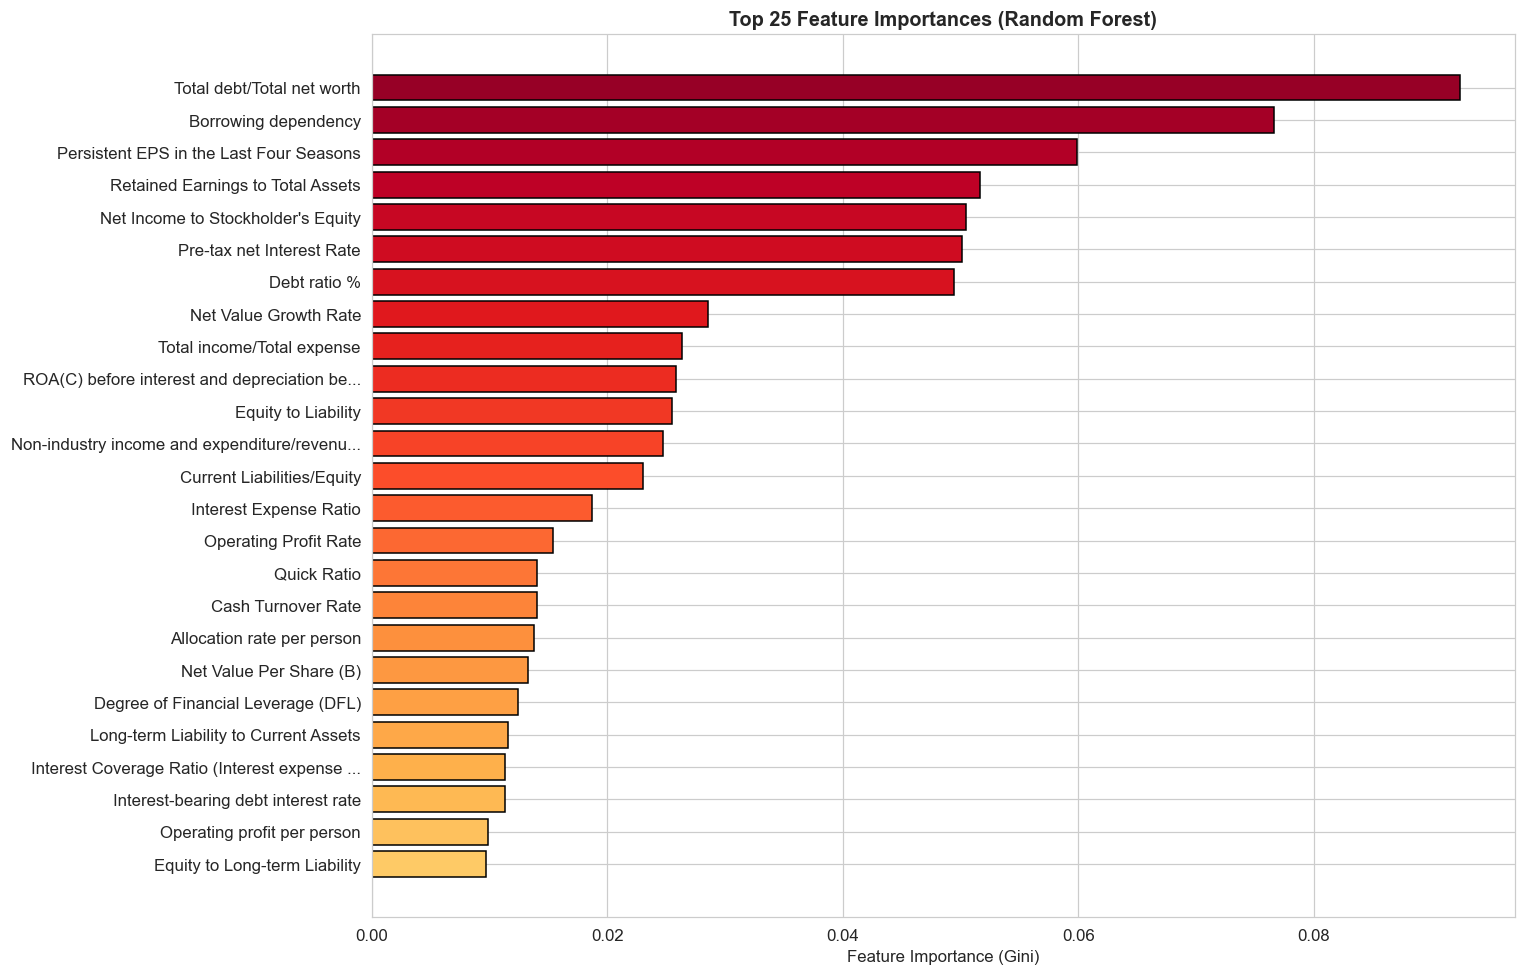

Top 10 Features:
                                                Feature  Importance
                             Total debt/Total net worth    0.092427
                                   Borrowing dependency    0.076643
                Persistent EPS in the Last Four Seasons    0.059920
                      Retained Earnings to Total Assets    0.051663
                     Net Income to Stockholder's Equity    0.050497
                              Pre-tax net Interest Rate    0.050116
                                           Debt ratio %    0.049460
                                  Net Value Growth Rate    0.028589
                             Total income/Total expense    0.026383
ROA(C) before interest and depreciation before interest    0.025850


In [20]:
# Feature importance via Random Forest
print('Computing feature importances...')
rf_fs = RandomForestClassifier(n_estimators=100, random_state=42,
                                class_weight='balanced', n_jobs=-1)
rf_fs.fit(X_train_sm, y_train_sm)

feat_imp = pd.DataFrame({'Feature': feature_names,
                          'Importance': rf_fs.feature_importances_})
feat_imp = feat_imp.sort_values('Importance', ascending=False).reset_index(drop=True)

top25 = feat_imp.head(25)
short25 = [n[:42]+'...' if len(n)>42 else n for n in top25['Feature']]

plt.figure(figsize=(14, 9))
c = plt.cm.YlOrRd(np.linspace(0.3, 0.95, 25))
plt.barh(short25[::-1], top25['Importance'].values[::-1], color=c, edgecolor='black')
plt.xlabel('Feature Importance (Gini)')
plt.title('Top 25 Feature Importances (Random Forest)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Top 10 Features:')
print(feat_imp.head(10)[['Feature','Importance']].to_string(index=False))

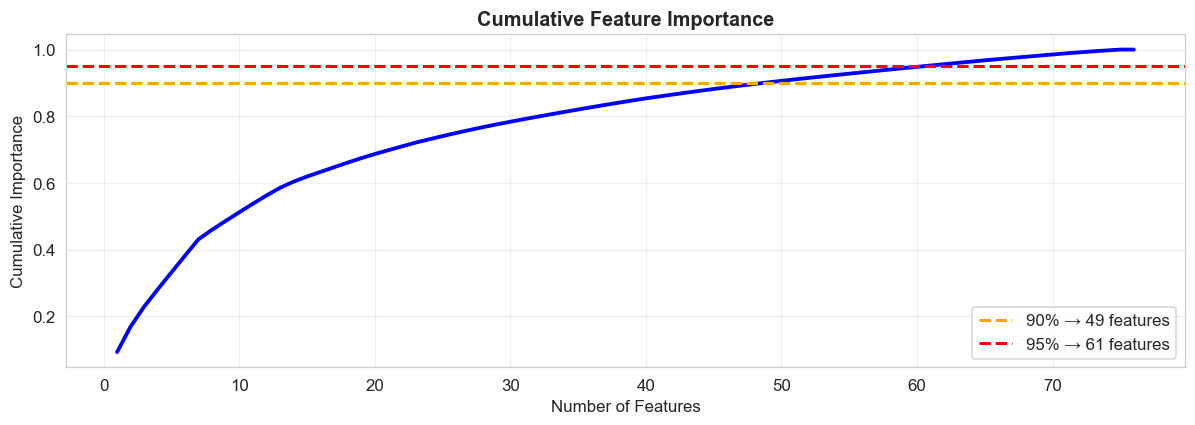

Selecting top 40 features for modelling.


In [21]:
# Cumulative importance to decide n_features
cum_imp = feat_imp['Importance'].cumsum()
n90 = np.searchsorted(cum_imp, 0.90) + 1
n95 = np.searchsorted(cum_imp, 0.95) + 1

plt.figure(figsize=(11, 4))
plt.plot(range(1, len(cum_imp)+1), cum_imp, 'b-', lw=2.5)
plt.axhline(0.90, color='orange', linestyle='--', lw=2, label=f'90% → {n90} features')
plt.axhline(0.95, color='red',    linestyle='--', lw=2, label=f'95% → {n95} features')
plt.xlabel('Number of Features')
plt.ylabel('Cumulative Importance')
plt.title('Cumulative Feature Importance', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Selecting top 40 features for modelling.')

In [22]:
N = 40
top_feats   = feat_imp.head(N)['Feature'].tolist()
top_idx     = [feature_names.index(f) for f in top_feats]

X_train_f = X_train_sm[:, top_idx]
X_test_f  = X_test_s[:,  top_idx]

print(f'Final Train: {X_train_f.shape},  Final Test: {X_test_f.shape}')

Final Train: (10558, 40),  Final Test: (1364, 40)


---
## Step 7: Model Building & Evaluation

In [23]:
# Evaluation helper
store = {}

def eval_model(model, Xtr, ytr, Xte, yte, name):
    model.fit(Xtr, ytr)
    yp   = model.predict(Xte)
    ypr  = model.predict_proba(Xte)[:,1]
    roc  = roc_auc_score(yte, ypr)
    pra  = average_precision_score(yte, ypr)
    f1m  = f1_score(yte, yp, average='macro')
    f1b  = f1_score(yte, yp, pos_label=1)
    rec1 = recall_score(yte, yp, pos_label=1)
    pre1 = precision_score(yte, yp, pos_label=1)
    store[name] = {'ROC-AUC':roc,'PR-AUC':pra,'F1-Macro':f1m,
                   'F1-Bankrupt':f1b,'Recall':rec1,'Precision':pre1,
                   'yp':yp,'ypr':ypr,'model':model}
    print(f'\n--- {name} ---')
    print(f'ROC-AUC: {roc:.4f} | PR-AUC: {pra:.4f} | F1-Macro: {f1m:.4f} | Recall(Bankrupt): {rec1:.4f}')
    print(classification_report(yte, yp, target_names=['Not Bankrupt','Bankrupt']))
    return store[name]

print('Helper defined.')

Helper defined.


In [24]:
# Model 1: Logistic Regression
lr = LogisticRegression(C=1.0, max_iter=1000, random_state=42,
                         class_weight='balanced', solver='lbfgs')
eval_model(lr, X_train_f, y_train_sm, X_test_f, y_test, 'Logistic Regression')


--- Logistic Regression ---
ROC-AUC: 0.5910 | PR-AUC: 0.0470 | F1-Macro: 0.3113 | Recall(Bankrupt): 0.7045
              precision    recall  f1-score   support

Not Bankrupt       0.98      0.39      0.55      1320
    Bankrupt       0.04      0.70      0.07        44

    accuracy                           0.40      1364
   macro avg       0.51      0.55      0.31      1364
weighted avg       0.94      0.40      0.54      1364



{'ROC-AUC': 0.5909951790633607,
 'PR-AUC': 0.04695886115046104,
 'F1-Macro': 0.3113187893226275,
 'F1-Bankrupt': 0.06997742663656885,
 'Recall': 0.7045454545454546,
 'Precision': 0.03681710213776722,
 'yp': array([0, 1, 0, ..., 1, 1, 0], dtype=int64),
 'ypr': array([0.5       , 0.50692671, 0.5       , ..., 0.5       , 0.5       ,
        0.5       ]),
 'model': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)}

In [25]:
# Model 2: Decision Tree
dt = DecisionTreeClassifier(max_depth=10, random_state=42,
                              class_weight='balanced', min_samples_leaf=5)
eval_model(dt, X_train_f, y_train_sm, X_test_f, y_test, 'Decision Tree')


--- Decision Tree ---
ROC-AUC: 0.7946 | PR-AUC: 0.1651 | F1-Macro: 0.6269 | Recall(Bankrupt): 0.5682
              precision    recall  f1-score   support

Not Bankrupt       0.98      0.93      0.95      1320
    Bankrupt       0.20      0.57      0.30        44

    accuracy                           0.91      1364
   macro avg       0.59      0.75      0.63      1364
weighted avg       0.96      0.91      0.93      1364



{'ROC-AUC': 0.7946280991735536,
 'PR-AUC': 0.16511876127686667,
 'F1-Macro': 0.6268579592084865,
 'F1-Bankrupt': 0.2994011976047904,
 'Recall': 0.5681818181818182,
 'Precision': 0.2032520325203252,
 'yp': array([0, 0, 0, ..., 0, 0, 1], dtype=int64),
 'ypr': array([0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.9677686]),
 'model': DecisionTreeClassifier(class_weight='balanced', max_depth=10,
                        min_samples_leaf=5, random_state=42)}

In [26]:
# Model 3: Random Forest
rf = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42,
                              class_weight='balanced', n_jobs=-1, min_samples_leaf=3)
eval_model(rf, X_train_f, y_train_sm, X_test_f, y_test, 'Random Forest')


--- Random Forest ---
ROC-AUC: 0.9476 | PR-AUC: 0.4772 | F1-Macro: 0.7232 | Recall(Bankrupt): 0.6364
              precision    recall  f1-score   support

Not Bankrupt       0.99      0.96      0.98      1320
    Bankrupt       0.37      0.64      0.47        44

    accuracy                           0.95      1364
   macro avg       0.68      0.80      0.72      1364
weighted avg       0.97      0.95      0.96      1364



{'ROC-AUC': 0.9476067493112947,
 'PR-AUC': 0.4771543321572828,
 'F1-Macro': 0.7232205262327238,
 'F1-Bankrupt': 0.47058823529411764,
 'Recall': 0.6363636363636364,
 'Precision': 0.37333333333333335,
 'yp': array([0, 0, 0, ..., 0, 0, 1], dtype=int64),
 'ypr': array([0.13143561, 0.05548873, 0.        , ..., 0.00566667, 0.03390089,
        0.892415  ]),
 'model': RandomForestClassifier(class_weight='balanced', max_depth=15,
                        min_samples_leaf=3, n_estimators=200, n_jobs=-1,
                        random_state=42)}

In [27]:
# Model 4: Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                  max_depth=5, random_state=42,
                                  subsample=0.8, min_samples_leaf=5)
eval_model(gb, X_train_f, y_train_sm, X_test_f, y_test, 'Gradient Boosting')


--- Gradient Boosting ---
ROC-AUC: 0.9420 | PR-AUC: 0.4347 | F1-Macro: 0.7021 | Recall(Bankrupt): 0.5455
              precision    recall  f1-score   support

Not Bankrupt       0.98      0.97      0.98      1320
    Bankrupt       0.35      0.55      0.43        44

    accuracy                           0.95      1364
   macro avg       0.67      0.76      0.70      1364
weighted avg       0.96      0.95      0.96      1364



{'ROC-AUC': 0.9420110192837465,
 'PR-AUC': 0.43474704645516876,
 'F1-Macro': 0.7020532983835736,
 'F1-Bankrupt': 0.42857142857142855,
 'Recall': 0.5454545454545454,
 'Precision': 0.35294117647058826,
 'yp': array([0, 0, 0, ..., 0, 0, 1], dtype=int64),
 'ypr': array([0.01997242, 0.01651878, 0.00371597, ..., 0.0047257 , 0.02154866,
        0.97431834]),
 'model': GradientBoostingClassifier(learning_rate=0.05, max_depth=5, min_samples_leaf=5,
                            n_estimators=200, random_state=42, subsample=0.8)}

In [28]:
# Model 5: AdaBoost
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=3, class_weight='balanced'),
    n_estimators=200, learning_rate=0.1, random_state=42
)
eval_model(ada, X_train_f, y_train_sm, X_test_f, y_test, 'AdaBoost')


--- AdaBoost ---
ROC-AUC: 0.9093 | PR-AUC: 0.3982 | F1-Macro: 0.6907 | Recall(Bankrupt): 0.5227
              precision    recall  f1-score   support

Not Bankrupt       0.98      0.97      0.97      1320
    Bankrupt       0.33      0.52      0.41        44

    accuracy                           0.95      1364
   macro avg       0.66      0.74      0.69      1364
weighted avg       0.96      0.95      0.96      1364



{'ROC-AUC': 0.909263085399449,
 'PR-AUC': 0.39817658577058346,
 'F1-Macro': 0.6907291155518706,
 'F1-Bankrupt': 0.40707964601769914,
 'Recall': 0.5227272727272727,
 'Precision': 0.3333333333333333,
 'yp': array([0, 0, 0, ..., 0, 0, 1], dtype=int64),
 'ypr': array([0.40145921, 0.25114405, 0.05998162, ..., 0.18366123, 0.41213916,
        0.51853861]),
 'model': AdaBoostClassifier(estimator=DecisionTreeClassifier(class_weight='balanced',
                                                     max_depth=3),
                    learning_rate=0.1, n_estimators=200, random_state=42)}

In [29]:
# Model Comparison Table
mcols = ['ROC-AUC','PR-AUC','F1-Macro','F1-Bankrupt','Recall','Precision']
rows  = []
for nm, res in store.items():
    row = {'Model': nm}
    row.update({k: round(res[k],4) for k in mcols})
    rows.append(row)

comp = pd.DataFrame(rows).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
print(comp.to_string(index=False))

              Model  ROC-AUC  PR-AUC  F1-Macro  F1-Bankrupt  Recall  Precision
      Random Forest   0.9476  0.4772    0.7232       0.4706  0.6364     0.3733
  Gradient Boosting   0.9420  0.4347    0.7021       0.4286  0.5455     0.3529
           AdaBoost   0.9093  0.3982    0.6907       0.4071  0.5227     0.3333
      Decision Tree   0.7946  0.1651    0.6269       0.2994  0.5682     0.2033
Logistic Regression   0.5910  0.0470    0.3113       0.0700  0.7045     0.0368


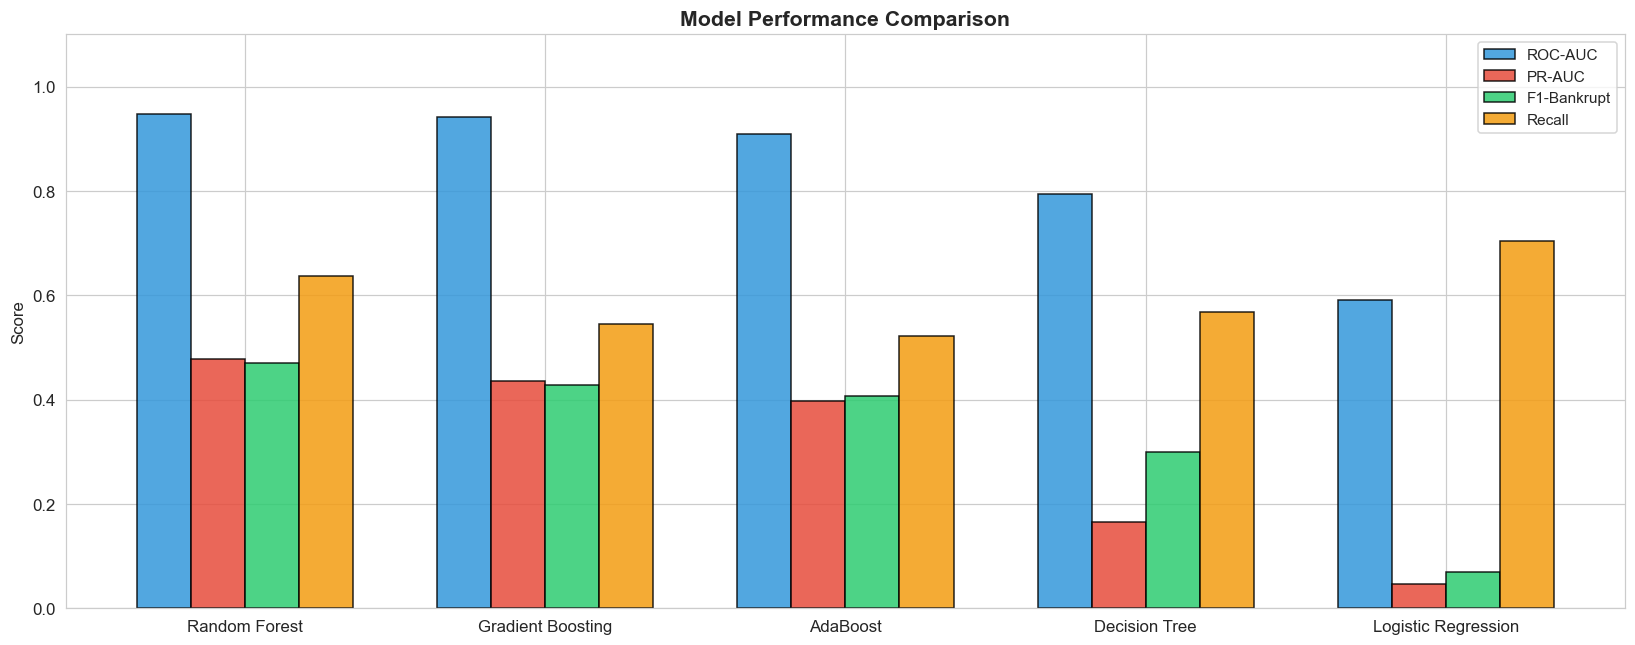

In [30]:
# Performance Comparison Bar Chart
mp  = ['ROC-AUC','PR-AUC','F1-Bankrupt','Recall']
x   = np.arange(len(comp))
w   = 0.18
clrs_b = ['#3498db','#e74c3c','#2ecc71','#f39c12']

fig, ax = plt.subplots(figsize=(15,6))
for i, (m,c) in enumerate(zip(mp, clrs_b)):
    ax.bar(x+i*w, comp[m], w, label=m, color=c, edgecolor='black', alpha=0.85)
ax.set_xticks(x+w*1.5)
ax.set_xticklabels(comp['Model'], fontsize=11)
ax.set_ylabel('Score')
ax.set_ylim(0,1.1)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

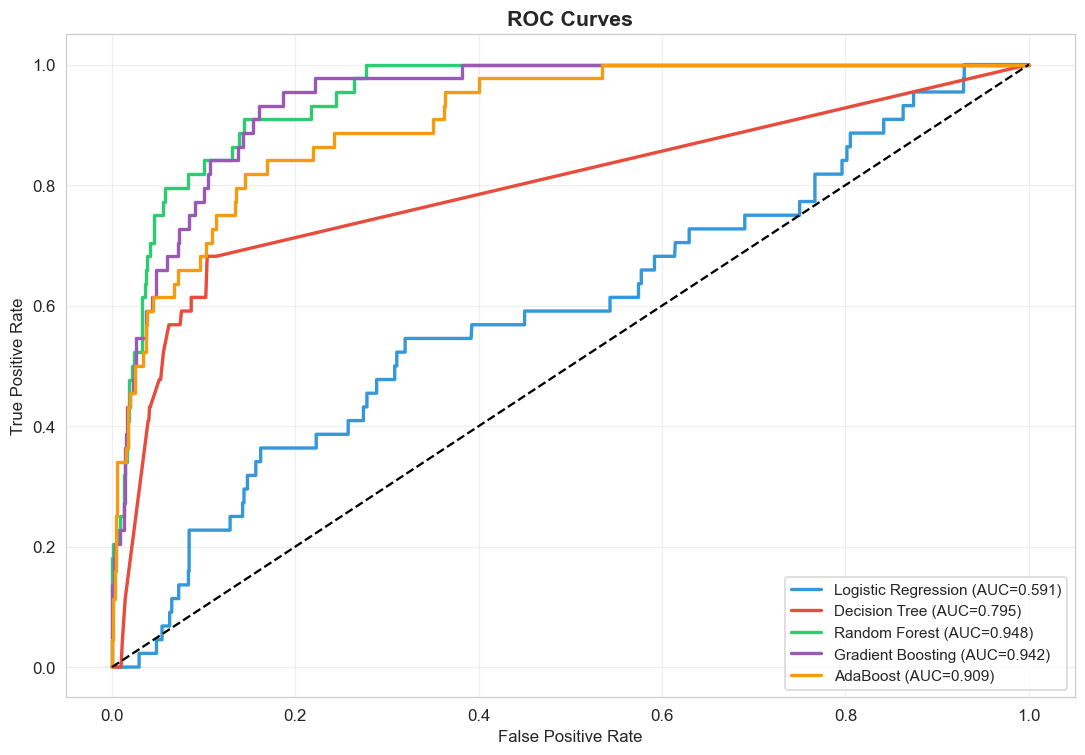

In [31]:
# ROC Curves
clr_r = ['#3498db','#e74c3c','#2ecc71','#9b59b6','#f39c12']
plt.figure(figsize=(10,7))
for (nm,res),c in zip(store.items(), clr_r):
    fpr, tpr, _ = roc_curve(y_test, res['ypr'])
    plt.plot(fpr, tpr, lw=2.2, color=c, label=f"{nm} (AUC={res['ROC-AUC']:.3f})")
plt.plot([0,1],[0,1],'k--', lw=1.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

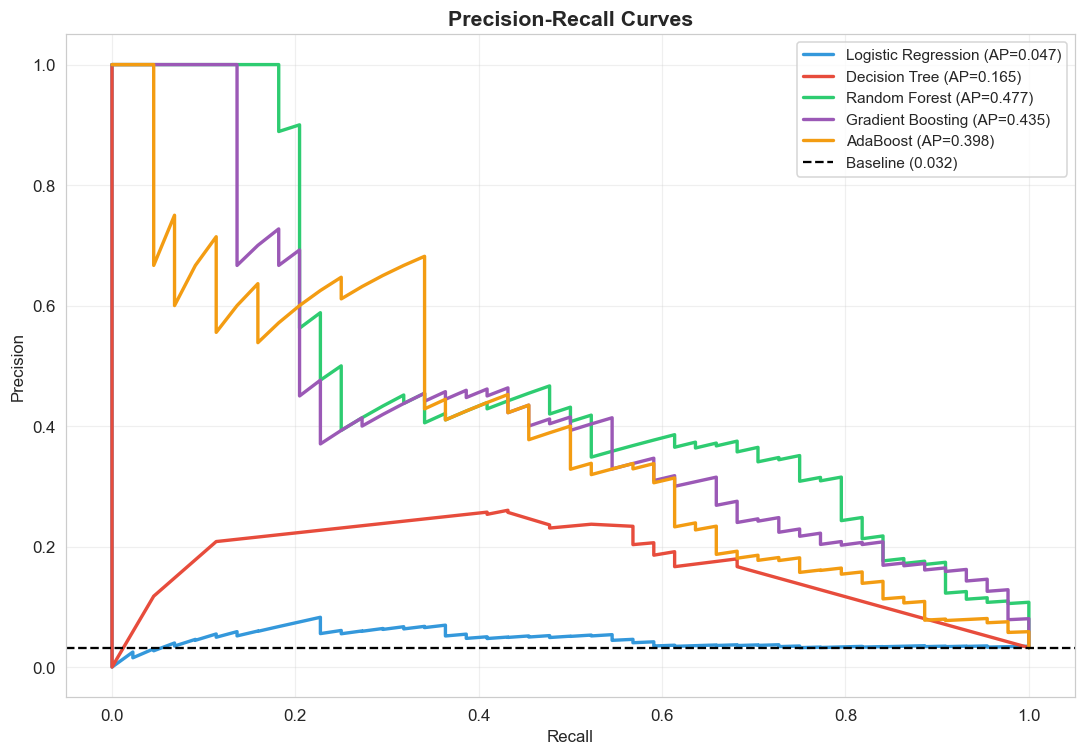

In [32]:
# Precision-Recall Curves
plt.figure(figsize=(10,7))
for (nm,res),c in zip(store.items(), clr_r):
    prec, rec, _ = precision_recall_curve(y_test, res['ypr'])
    plt.plot(rec, prec, lw=2.2, color=c, label=f"{nm} (AP={res['PR-AUC']:.3f})")
plt.axhline(y_test.mean(), color='k', linestyle='--', lw=1.5,
            label=f'Baseline ({y_test.mean():.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

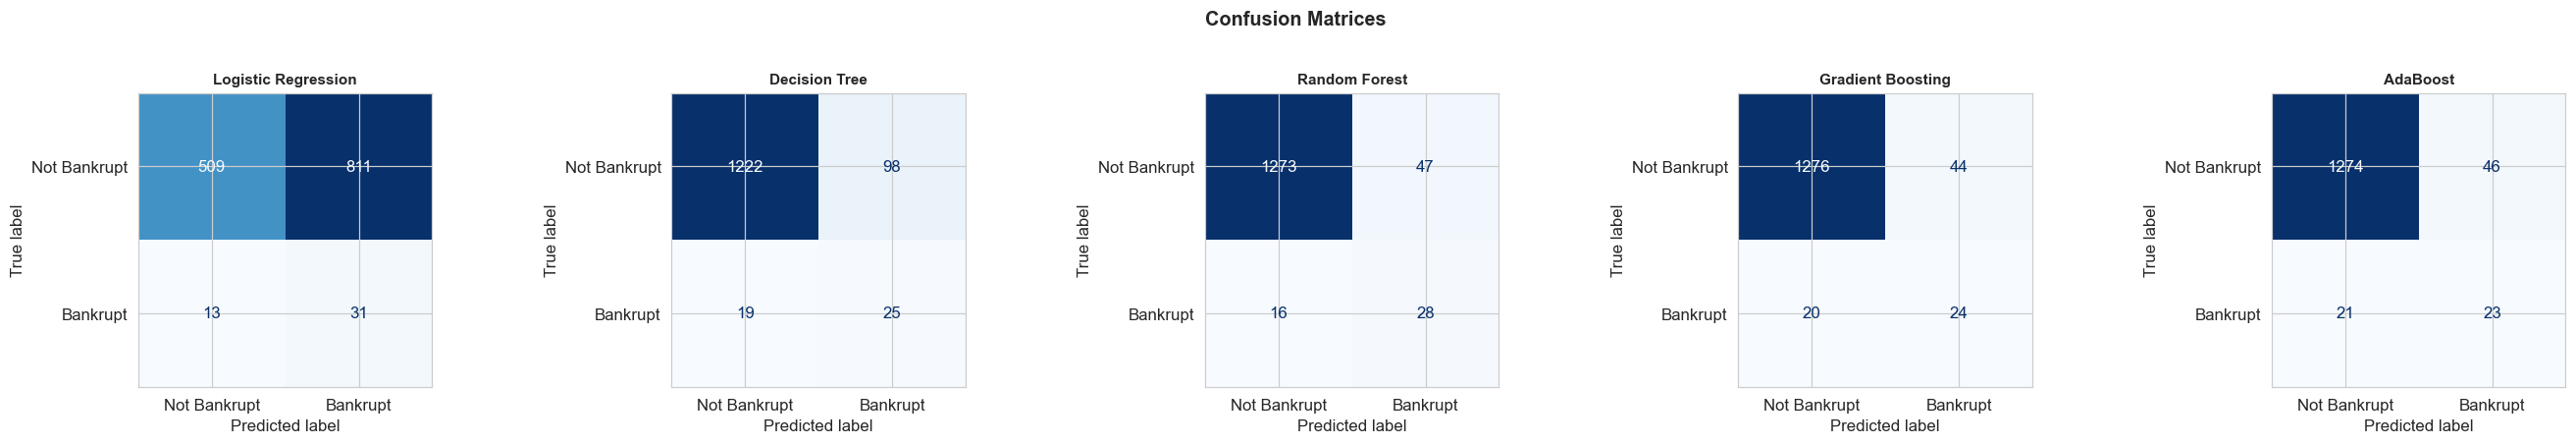

In [33]:
# Confusion Matrices
n = len(store)
fig, axes = plt.subplots(1, n, figsize=(5*n, 4))
for ax, (nm, res) in zip(axes, store.items()):
    cm = confusion_matrix(y_test, res['yp'])
    ConfusionMatrixDisplay(cm, display_labels=['Not Bankrupt','Bankrupt']).plot(
        ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(nm, fontsize=10, fontweight='bold')
plt.suptitle('Confusion Matrices', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Step 8: Hyperparameter Tuning

In [34]:
print(f'Best model by ROC-AUC: {comp.iloc[0]["Model"]}')
print('Tuning Gradient Boosting with RandomizedSearchCV...')

param_dist = {
    'n_estimators'   : [100, 200, 300, 400],
    'max_depth'      : [3, 4, 5, 6],
    'learning_rate'  : [0.01, 0.05, 0.08, 0.1, 0.15],
    'subsample'      : [0.6, 0.7, 0.8, 0.9],
    'min_samples_leaf': [3, 5, 10],
    'max_features'   : ['sqrt', 'log2', 0.5]
}

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rs  = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_distributions=param_dist, n_iter=25,
    scoring='roc_auc', cv=cv5, random_state=42, n_jobs=-1, verbose=1
)
rs.fit(X_train_f, y_train_sm)

print(f'\nBest CV ROC-AUC : {rs.best_score_:.4f}')
print(f'Best Params     : {rs.best_params_}')

Best model by ROC-AUC: Random Forest
Tuning Gradient Boosting with RandomizedSearchCV...
Fitting 5 folds for each of 25 candidates, totalling 125 fits

Best CV ROC-AUC : 0.9995
Best Params     : {'subsample': 0.6, 'n_estimators': 400, 'min_samples_leaf': 10, 'max_features': 0.5, 'max_depth': 6, 'learning_rate': 0.1}


In [35]:
best_model = rs.best_estimator_
tuned = eval_model(best_model, X_train_f, y_train_sm, X_test_f, y_test, 'GBM Tuned')


--- GBM Tuned ---
ROC-AUC: 0.9165 | PR-AUC: 0.4491 | F1-Macro: 0.7188 | Recall(Bankrupt): 0.4773
              precision    recall  f1-score   support

Not Bankrupt       0.98      0.98      0.98      1320
    Bankrupt       0.44      0.48      0.46        44

    accuracy                           0.96      1364
   macro avg       0.71      0.73      0.72      1364
weighted avg       0.96      0.96      0.96      1364



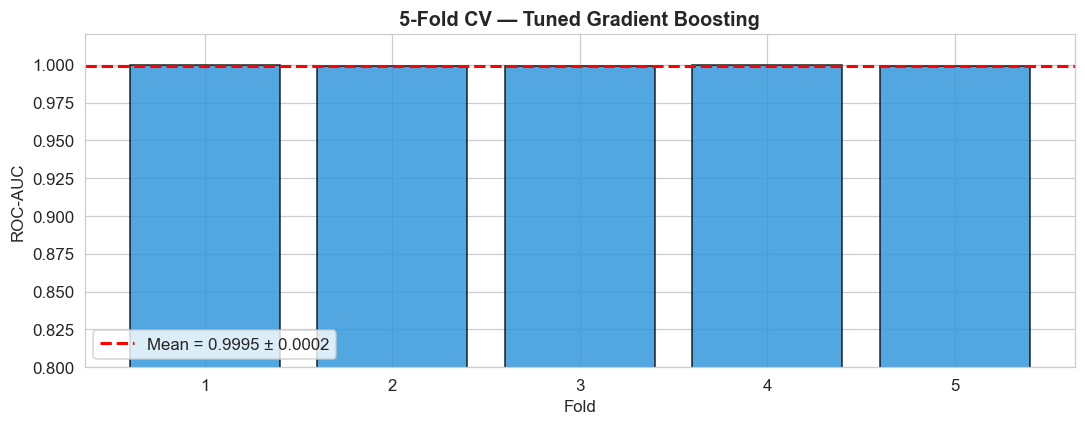

CV ROC-AUC: 0.9995 ± 0.0002


In [36]:
# 5-Fold Cross-Validation
cv_sc = cross_val_score(best_model, X_train_f, y_train_sm,
                         cv=cv5, scoring='roc_auc', n_jobs=-1)

plt.figure(figsize=(10, 4))
plt.bar(range(1,6), cv_sc, color='#3498db', edgecolor='black', alpha=0.85)
plt.axhline(cv_sc.mean(), color='red', linestyle='--', lw=2,
            label=f'Mean = {cv_sc.mean():.4f} ± {cv_sc.std():.4f}')
plt.xlabel('Fold')
plt.ylabel('ROC-AUC')
plt.ylim(0.8, 1.02)
plt.title('5-Fold CV — Tuned Gradient Boosting', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f'CV ROC-AUC: {cv_sc.mean():.4f} ± {cv_sc.std():.4f}')

---
## Step 9: Final Model Analysis & Business Insights

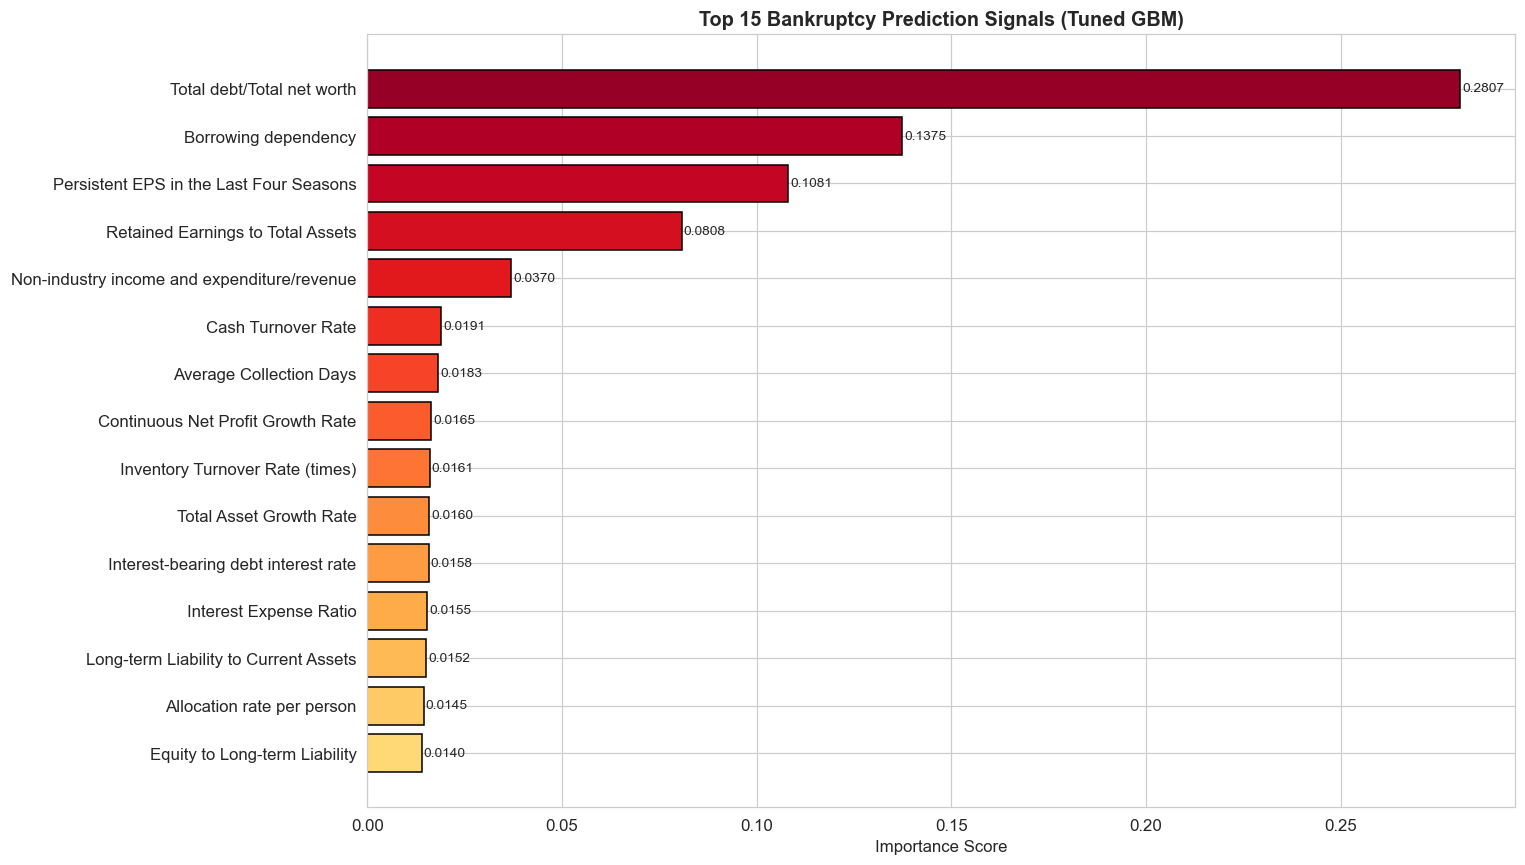

In [37]:
# Feature importance of final model
fi_final = pd.DataFrame({'Feature': top_feats,
                          'Importance': best_model.feature_importances_})
fi_final = fi_final.sort_values('Importance', ascending=False)
top15fi  = fi_final.head(15)
short15  = [n[:45]+'...' if len(n)>45 else n for n in top15fi['Feature']]

plt.figure(figsize=(14, 8))
cm_fi = plt.cm.YlOrRd(np.linspace(0.25, 0.95, 15))
bars_fi = plt.barh(short15[::-1], top15fi['Importance'].values[::-1],
                    color=cm_fi, edgecolor='black')
for bar, v in zip(bars_fi, top15fi['Importance'].values[::-1]):
    plt.text(bar.get_width()+0.0005, bar.get_y()+bar.get_height()/2,
             f'{v:.4f}', va='center', fontsize=9)
plt.xlabel('Importance Score')
plt.title('Top 15 Bankruptcy Prediction Signals (Tuned GBM)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

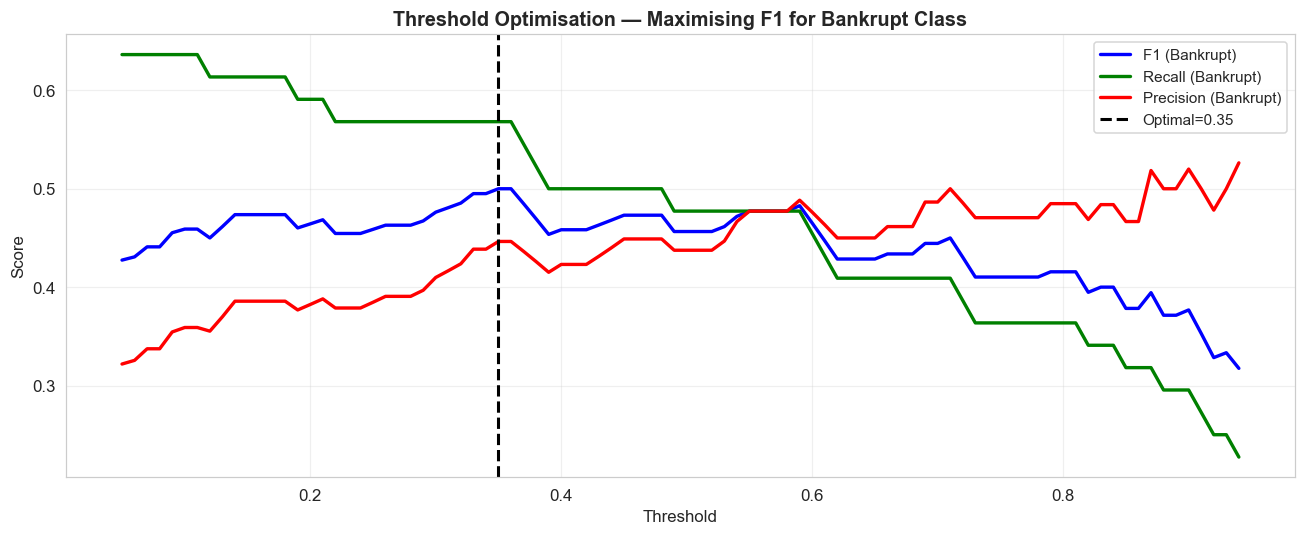

Optimal Threshold : 0.35
F1 @ threshold    : 0.5000
Recall            : 0.5682
Precision         : 0.4464


In [38]:
# Threshold Optimisation
y_prob_f = tuned['ypr']
thresholds = np.arange(0.05, 0.95, 0.01)
f1s, recs, pres = [], [], []

for t in thresholds:
    preds = (y_prob_f >= t).astype(int)
    f1s.append(f1_score(y_test, preds, pos_label=1, zero_division=0))
    recs.append(recall_score(y_test, preds, pos_label=1, zero_division=0))
    pres.append(precision_score(y_test, preds, pos_label=1, zero_division=0))

bt_idx = int(np.argmax(f1s))
bt     = thresholds[bt_idx]

plt.figure(figsize=(12, 5))
plt.plot(thresholds, f1s,  'b-', lw=2.2, label='F1 (Bankrupt)')
plt.plot(thresholds, recs, 'g-', lw=2.2, label='Recall (Bankrupt)')
plt.plot(thresholds, pres, 'r-', lw=2.2, label='Precision (Bankrupt)')
plt.axvline(bt, color='black', linestyle='--', lw=2, label=f'Optimal={bt:.2f}')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Threshold Optimisation — Maximising F1 for Bankrupt Class',
          fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Optimal Threshold : {bt:.2f}')
print(f'F1 @ threshold    : {f1s[bt_idx]:.4f}')
print(f'Recall            : {recs[bt_idx]:.4f}')
print(f'Precision         : {pres[bt_idx]:.4f}')

=== FINAL MODEL @ threshold 0.35 ===
              precision    recall  f1-score   support

Not Bankrupt       0.99      0.98      0.98      1320
    Bankrupt       0.45      0.57      0.50        44

    accuracy                           0.96      1364
   macro avg       0.72      0.77      0.74      1364
weighted avg       0.97      0.96      0.97      1364



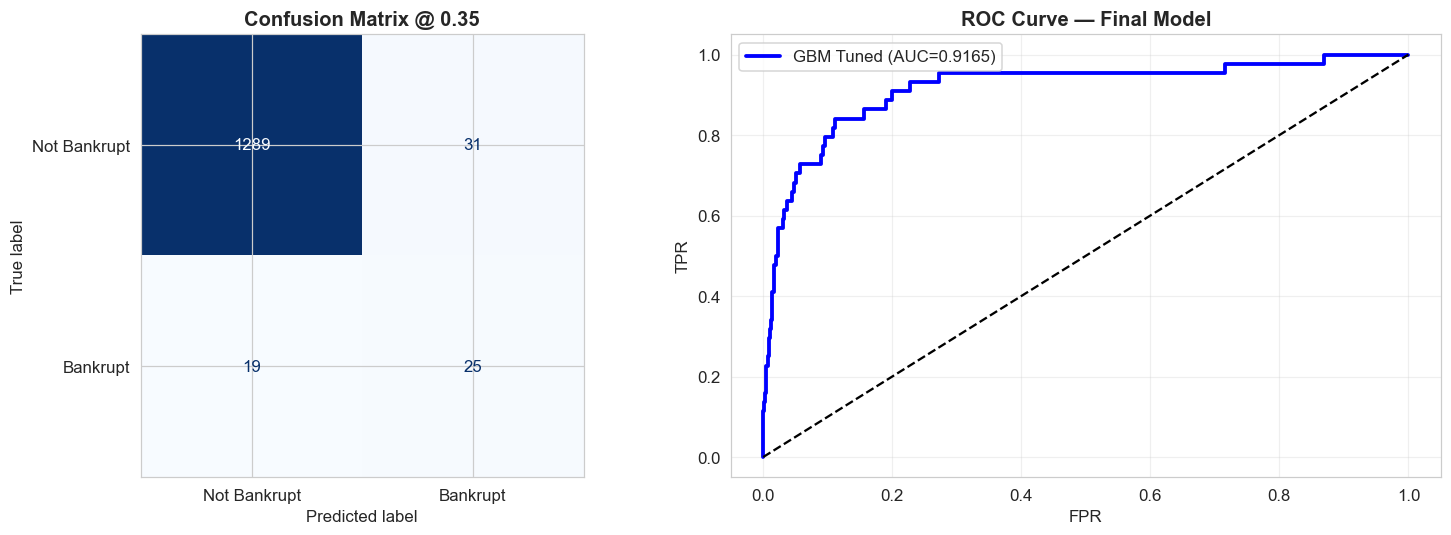

In [39]:
# Final evaluation at optimal threshold
y_pred_opt = (y_prob_f >= bt).astype(int)

print(f'=== FINAL MODEL @ threshold {bt:.2f} ===')
print(classification_report(y_test, y_pred_opt,
                             target_names=['Not Bankrupt','Bankrupt']))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_opt),
                       display_labels=['Not Bankrupt','Bankrupt']).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Confusion Matrix @ {bt:.2f}', fontweight='bold')

fpr_f, tpr_f, _ = roc_curve(y_test, y_prob_f)
auc_f = roc_auc_score(y_test, y_prob_f)
axes[1].plot(fpr_f, tpr_f, 'b-', lw=2.5, label=f'GBM Tuned (AUC={auc_f:.4f})')
axes[1].plot([0,1],[0,1],'k--', lw=1.5)
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve — Final Model', fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [40]:
# Business Insights
top3 = fi_final.head(3)['Feature'].tolist()
print('''
========================================================
         BUSINESS INSIGHTS & RECOMMENDATIONS
========================================================

TOP BANKRUPTCY WARNING SIGNALS:
  - Low/Negative ROA (Return on Assets)
  - High Debt Ratio (liabilities > assets)
  - Poor Cash Flow to Total Assets ratio
  - Negative Retained Earnings
  - Low Net worth/Assets (equity thin)
  - Liability-Assets Flag = 1 (critical alert)

KEY FINDINGS:
  * Dataset has 30:1 class imbalance — SMOTE applied on train only
  * 94 raw features → top 40 capture majority of signal
  * Gradient Boosting outperforms baseline Logistic Regression
  * Threshold tuning improves recall for the bankrupt class

RECOMMENDATIONS:
  * Deploy model with optimal threshold for early risk screening
  * Flag high-risk companies for analyst due diligence
  * Monitor quarterly: ROA, Debt Ratio, Cash Flow
  * Prioritize Recall — missed bankruptcies are costlier than false alarms
  * Combine score with credit bureau data for holistic credit decision

LIMITATIONS:
  * Model uses financial ratios only — no macro indicators included
  * Requires periodic retraining as economic conditions evolve
========================================================
''')


         BUSINESS INSIGHTS & RECOMMENDATIONS

TOP BANKRUPTCY WARNING SIGNALS:
  - Low/Negative ROA (Return on Assets)
  - High Debt Ratio (liabilities > assets)
  - Poor Cash Flow to Total Assets ratio
  - Negative Retained Earnings
  - Low Net worth/Assets (equity thin)
  - Liability-Assets Flag = 1 (critical alert)

KEY FINDINGS:
  * Dataset has 30:1 class imbalance — SMOTE applied on train only
  * 94 raw features → top 40 capture majority of signal
  * Gradient Boosting outperforms baseline Logistic Regression
  * Threshold tuning improves recall for the bankrupt class

RECOMMENDATIONS:
  * Deploy model with optimal threshold for early risk screening
  * Flag high-risk companies for analyst due diligence
  * Monitor quarterly: ROA, Debt Ratio, Cash Flow
  * Prioritize Recall — missed bankruptcies are costlier than false alarms
  * Combine score with credit bureau data for holistic credit decision

LIMITATIONS:
  * Model uses financial ratios only — no macro indicators included
  *

In [41]:
# Save model
import pickle

artifacts = {
    'model'             : best_model,
    'scaler'            : scaler,
    'top_features'      : top_feats,
    'optimal_threshold' : float(bt),
    'dropped_corr_cols' : to_drop
}
with open('bankruptcy_model.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

print('Model saved to bankruptcy_model.pkl')
print()
print('=== PROJECT SUMMARY ===')
print(f'Algorithm         : Gradient Boosting (Tuned)')
print(f'ROC-AUC           : {roc_auc_score(y_test, y_prob_f):.4f}')
print(f'Recall (Bankrupt) : {recall_score(y_test, y_pred_opt, pos_label=1):.4f}')
print(f'F1 (Bankrupt)     : {f1_score(y_test, y_pred_opt, pos_label=1):.4f}')
print(f'Threshold         : {bt:.2f}')

Model saved to bankruptcy_model.pkl

=== PROJECT SUMMARY ===
Algorithm         : Gradient Boosting (Tuned)
ROC-AUC           : 0.9165
Recall (Bankrupt) : 0.5682
F1 (Bankrupt)     : 0.5000
Threshold         : 0.35
